In [3]:
# ==========================================
# Import Required Libraries
# ==========================================

import os
import glob
import shutil
import uuid

import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# Fix random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# ==========================================
# Dataset Paths and Image Configuration
# ==========================================

train_dataset_dir = "data/train"
validation_dataset_dir = "data/validation"
test_dataset_dir = "data/test"

# Image size for Xception
width = 224
height = 224

target_size = (width, height)
input_shape = (width, height, 3)

print("Dataset directories configured successfully.")

Dataset directories configured successfully.


In [5]:
# ==========================================
# Create Dataset Splits
# ==========================================

def create_splits(test_size=0.15, validation_size=0.15):

    try:
        all_images = glob.glob(f"{train_dataset_dir}/*/*.*")
        np.random.shuffle(all_images)

        total_images = len(all_images)

        test_split = int(total_images * test_size)
        val_split = int(total_images * validation_size)

        test_images = all_images[:test_split]
        val_images = all_images[test_split:test_split+val_split]
        train_images = all_images[test_split+val_split:]

        print("Dataset split created successfully")

        return train_images, val_images, test_images

    except Exception as e:
        print("Error while creating dataset split:", e)

In [6]:
# ==========================================
# Image Preprocessing Function
# ==========================================

def preprocessing_function(img, pretrained=True):

    try:
        if pretrained:
            img = tf.keras.applications.xception.preprocess_input(img)
        else:
            img = img.astype(np.float32) / 255.0

        return img

    except Exception as e:
        print("Error in preprocessing:", e)
        return img

In [7]:
# ==========================================
# Data Generators
# ==========================================

def image_data_generator():

    try:

        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocessing_function,
            rotation_range=20,
            zoom_range=0.15,
            horizontal_flip=True
        )

        test_datagen = ImageDataGenerator(
            preprocessing_function=preprocessing_function
        )

        train_generator = train_datagen.flow_from_directory(
            train_dataset_dir,
            target_size=target_size,
            batch_size=32,
            class_mode='binary'
        )

        validation_generator = test_datagen.flow_from_directory(
            validation_dataset_dir,
            target_size=target_size,
            batch_size=32,
            class_mode='binary'
        )

        test_generator = test_datagen.flow_from_directory(
            test_dataset_dir,
            target_size=target_size,
            batch_size=32,
            class_mode='binary',
            shuffle=False
        )

        return train_generator, validation_generator, test_generator

    except Exception as e:
        print("Error creating data generators:", e)

In [8]:
##Load Generators
train_generator, validation_generator, test_generator = image_data_generator()

Found 24576 images belonging to 2 classes.
Found 6802 images belonging to 2 classes.
Found 6823 images belonging to 2 classes.


In [9]:
# ==========================================
# Build Cancer Detection Model
# ==========================================

def cancer_detector(pretrained=True):

    try:

        base_model = tf.keras.applications.Xception(
            include_top=False,
            weights='imagenet',
            input_shape=input_shape
        )

        x = base_model.output
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dense(256, activation='relu')(x)
        x = tf.keras.layers.Dense(64, activation='relu')(x)
        outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

        model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

        print("Model created successfully")

        return model

    except Exception as e:
        print("Error building model:", e)

In [10]:
model = cancer_detector()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

model.summary()



Model created successfully
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 111, 111, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 111, 111, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 111, 111, 32)         0      

In [11]:
# ==========================================
# Section 9: Train Model OR Load Existing Model
# ==========================================

import os
import logging
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ------------------------------------------
# Configure Logging
# ------------------------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)

logger = logging.getLogger(__name__)

MODEL_PATH = "cancer_detector.h5"

try:

    # ------------------------------------------
    # Check if model already exists
    # ------------------------------------------

    if os.path.exists(MODEL_PATH):

        logger.info("Existing trained model detected.")
        logger.info("Loading model from disk...")

        model = tf.keras.models.load_model(MODEL_PATH)

        logger.info("Model loaded successfully.")

    else:

        logger.info("No saved model found.")
        logger.info("Starting model training...")

        # ------------------------------------------
        # Callbacks
        # ------------------------------------------

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        checkpoint = ModelCheckpoint(
            MODEL_PATH,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )

        # ------------------------------------------
        # Train Model
        # ------------------------------------------

        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=30,
            callbacks=[early_stop, checkpoint]
        )

        logger.info("Training completed successfully.")

        # ------------------------------------------
        # Save Final Model
        # ------------------------------------------

        model.save(MODEL_PATH)

        logger.info(f"Model saved successfully at {MODEL_PATH}")

except Exception as e:

    logger.error("Error occurred during training or loading process.")
    logger.exception(e)

2026-03-14 16:54:10,097 | INFO | Existing trained model detected.
2026-03-14 16:54:10,098 | INFO | Loading model from disk...
2026-03-14 16:54:15,373 | INFO | Model loaded successfully.


In [12]:
# Validation evaluation
model.evaluate(validation_generator)

# Test evaluation
model.evaluate(test_generator)

2026-03-14 16:54:22,014 | WARNING | From C:\Personal Projects\JN\bcd-env\lib\site-packages\keras\src\utils\tf_utils.py:492: The name tf.ragged.RaggedTensorValue is deprecated. Please use tf.compat.v1.ragged.RaggedTensorValue instead.



214/214 [==============================] - 329s 2s/step - loss: 2.0045 - accuracy: 0.4475 - precision: 0.6160 - recall: 0.0599


[2.0045342445373535,
 0.44745713472366333,
 0.6159999966621399,
 0.05989110842347145]

214/214 [==============================] - 343s 2s/step


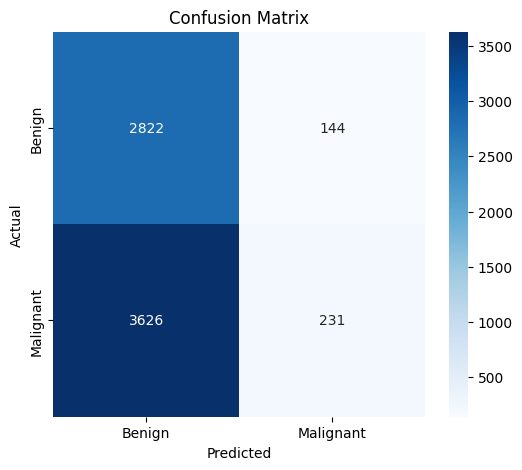

In [13]:
# ==========================================
# Confusion Matrix
# ==========================================

predictions = model.predict(test_generator)
predictions = (predictions > 0.5).astype(int).flatten()

y_true = test_generator.classes

cm = confusion_matrix(y_true, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign","Malignant"],
    yticklabels=["Benign","Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
print(classification_report(
    y_true,
    predictions,
    target_names=["Benign","Malignant"]
))

              precision    recall  f1-score   support

      Benign       0.44      0.95      0.60      2966
   Malignant       0.62      0.06      0.11      3857

    accuracy                           0.45      6823
   macro avg       0.53      0.51      0.35      6823
weighted avg       0.54      0.45      0.32      6823



214/214 [==============================] - 300s 1s/step


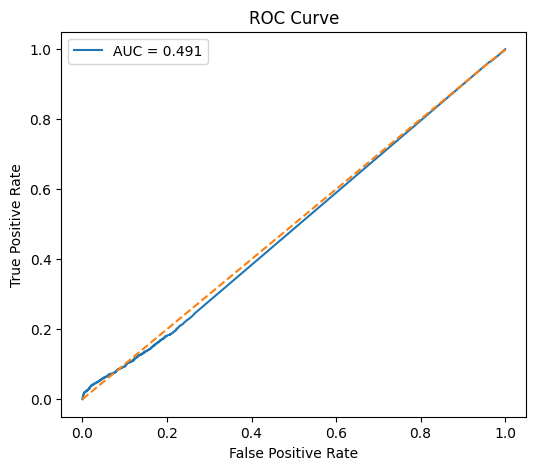

In [15]:
# ==========================================
# ROC Curve
# ==========================================

pred_probs = model.predict(test_generator).ravel()

fpr, tpr, thresholds = roc_curve(y_true, pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
model = tf.keras.models.load_model('cancer_detector.h5')
model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),       
            loss='binary_crossentropy',
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ])

In [17]:
class_dict = {'benign': 0, 'malignant': 1}
class_dict_rev = {0: 'benign', 1: 'malignant'}

In [18]:
def inference(image_path):
    image_path = image_path.replace('\\', '/')
    img = cv.imread(image_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, target_size)
    img = np.expand_dims(img, axis=0)
    img = preprocessing_function(img)
    prediction = model.predict(img)
    prediction = np.squeeze(prediction)
    prediction = prediction > 0.5
    prediction = prediction.astype('int')
    prediction = class_dict_rev[prediction]
    return prediction

In [19]:
inference('data/test/benign/20586908 (17).png')

1/1 [==============================] - 1s 1s/step


'benign'

In [20]:
inference('data/test/malignant/20586934 (5).png')

1/1 [==============================] - 0s 170ms/step


'benign'